In [1]:
from pathlib import Path

import pandas as pd


dataset = Path("../data/raw/transactional-sample.csv")

df = pd.read_csv(dataset)

print(f"Dataset: {df.shape[0]:,} transações")
print(f"Colunas: {df.shape[1]}")

Dataset: 3,199 transações
Colunas: 8


In [2]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

print(f"Período inicial: {df['transaction_date'].min()}")
print(f"Período final:   {df['transaction_date'].max()}")

Período inicial: 2019-11-01 01:27:15.811098
Período final:   2019-12-01 23:16:32.812632


In [3]:
total_transactions = len(df)
total_chargebacks = int(df["has_cbk"].sum())
chargeback_rate = df["has_cbk"].mean()

print(f"Total de transações: {total_transactions:,}")
print(f"Total de chargebacks: {total_chargebacks:,}")
print(f"Taxa de chargeback: {chargeback_rate:.2%}")

Total de transações: 3,199
Total de chargebacks: 391
Taxa de chargeback: 12.22%


In [4]:
chargeback_distribution = (
    df["has_cbk"]
    .value_counts()
    .rename(index={False: "Non-chargeback", True: "Chargeback"})
    .rename("transactions")
    .to_frame()
)

chargeback_distribution["percentage"] = (
    chargeback_distribution["transactions"]
    / total_transactions
    * 100
)

chargeback_distribution

,transactions,percentage
has_cbk,,
Non-chargeback,2808,87.77743
Chargeback,391,12.22257


In [5]:
chargeback_distribution_display = chargeback_distribution.copy()

chargeback_distribution_display["percentage"] = (
    chargeback_distribution_display["percentage"]
    .map(lambda x: f"{x:.2f}%".replace(".", ","))
)

chargeback_distribution_display

,transactions,percentage
has_cbk,,
Non-chargeback,2808,"87,78%"
Chargeback,391,"12,22%"


In [6]:
amount_summary = df["transaction_amount"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

amount_summary


count    3199.000000
mean      767.812904
std       889.095904
min         1.220000
25%       205.235000
50%       415.940000
75%       981.680000
90%      2074.934000
95%      2775.272000
99%      4028.550000
max      4097.210000
Name: transaction_amount, dtype: float64

In [7]:
amount_by_chargeback = (
    df.groupby("has_cbk")["transaction_amount"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        max="max",
    )
    .rename(index={False: "Non-chargeback", True: "Chargeback"})
)

amount_by_chargeback

,count,mean,median,std,min,q25,q75,max
has_cbk,,,,,,,,
Non-chargeback,2808,672.324380,360.315,797.463853,1.22,191.285,812.5775,4091.83
Chargeback,391,1453.571918,999.470,1169.491346,2.89,565.580,2140.6800,4097.21


In [8]:
mean_difference = (
    amount_by_chargeback.loc["Chargeback", "mean"]
    - amount_by_chargeback.loc["Non-chargeback", "mean"]
)

median_difference = (
    amount_by_chargeback.loc["Chargeback", "median"]
    - amount_by_chargeback.loc["Non-chargeback", "median"]
)

print(f"Diferença de média: {mean_difference:.2f}")
print(f"Diferença de mediana: {median_difference:.2f}")

Diferença de média: 781.25
Diferença de mediana: 639.15


Transactions associated with chargebacks show a markedly higher transaction amount distribution than non-chargeback transactions.

In [9]:
import matplotlib.pyplot as plt

<Figure size 800x500 with 0 Axes>

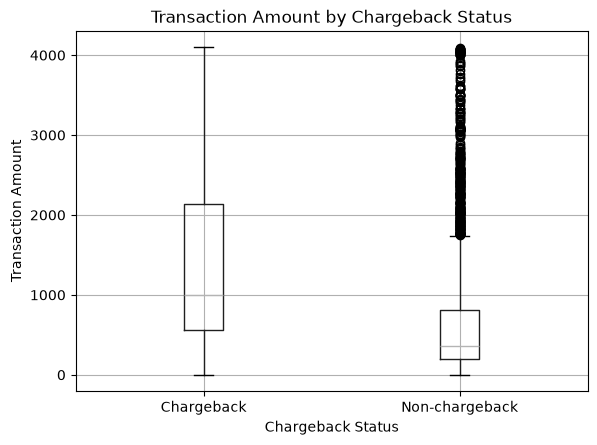

In [10]:
plot_df = df.copy()

plot_df["chargeback_status"] = plot_df["has_cbk"].map({
    False: "Non-chargeback",
    True: "Chargeback",
})

plt.figure(figsize=(8, 5))

plot_df.boxplot(
    column="transaction_amount",
    by="chargeback_status",
)

plt.title("Transaction Amount by Chargeback Status")
plt.suptitle("")
plt.xlabel("Chargeback Status")
plt.ylabel("Transaction Amount")

plt.show()

### Initial Finding — Transaction Amount

Transactions associated with chargebacks show a substantially higher transaction amount distribution than non-chargeback transactions.

The median transaction amount is approximately 999.47 for chargeback transactions versus 360.32 for non-chargeback transactions. The difference is also observed in the upper quartile, indicating that the shift is not driven only by a small number of extreme values.

This suggests that transaction amount may be a relevant risk signal for further investigation. However, the analysis does not imply that high-value transactions are inherently fraudulent, since the non-chargeback population also contains high-value transactions.

In [11]:

#Agora queremos verificar:

#A taxa de chargeback aumenta conforme aumenta o valor da transação?

amount_bins = [0, 250, 500, 1000, 2000, 3000, float("inf")]
amount_labels = [
    "Até 250",
    "250–500",
    "500–1.000",
    "1.000–2.000",
    "2.000–3.000",
    "Acima de 3.000",
]

df["amount_range"] = pd.cut(
    df["transaction_amount"],
    bins=amount_bins,
    labels=amount_labels,
    include_lowest=True,
)

chargeback_by_amount_range = (
    df.groupby("amount_range", observed=False)["has_cbk"]
    .agg(
        transactions="count",
        chargebacks="sum",
        chargeback_rate="mean",
    )
)

chargeback_by_amount_range["chargeback_rate"] *= 100

chargeback_by_amount_range

,transactions,chargebacks,chargeback_rate
amount_range,,,
Até 250,1010,27,2.673267
250–500,769,42,5.461638
500–1.000,640,127,19.843750
1.000–2.000,423,75,17.730496
2.000–3.000,215,67,31.162791
Acima de 3.000,142,53,37.323944


In [12]:
chargeback_by_amount_range_display = chargeback_by_amount_range.copy()

chargeback_by_amount_range_display["chargeback_rate"] = (
    chargeback_by_amount_range_display["chargeback_rate"]
    .map(lambda x: f"{x:.2f}%".replace(".", ","))
)

chargeback_by_amount_range_display

,transactions,chargebacks,chargeback_rate
amount_range,,,
Até 250,1010,27,"2,67%"
250–500,769,42,"5,46%"
500–1.000,640,127,"19,84%"
1.000–2.000,423,75,"17,73%"
2.000–3.000,215,67,"31,16%"
Acima de 3.000,142,53,"37,32%"


In [13]:
daily_activity = (
    df.set_index("transaction_date")
    .resample("D")
    .agg(
        transactions=("transaction_id", "count"),
        chargebacks=("has_cbk", "sum"),
        chargeback_rate=("has_cbk", "mean"),
    )
)

daily_activity["chargeback_rate"] *= 100

daily_activity.head()

,transactions,chargebacks,chargeback_rate
transaction_date,,,
2019-11-01,23,3,13.043478
2019-11-02,25,3,12.000000
2019-11-03,34,5,14.705882
2019-11-04,48,4,8.333333
2019-11-05,26,0,0.000000


In [14]:
daily_activity_display = daily_activity.copy()

daily_activity_display["chargeback_rate"] = (
    daily_activity_display["chargeback_rate"]
    .map(lambda x: f"{x:.2f}%".replace(".", ","))
)

daily_activity_display

,transactions,chargebacks,chargeback_rate
transaction_date,,,
2019-11-01,23,3,"13,04%"
2019-11-02,25,3,"12,00%"
2019-11-03,34,5,"14,71%"
2019-11-04,48,4,"8,33%"
2019-11-05,26,0,"0,00%"
2019-11-06,14,1,"7,14%"
2019-11-07,39,1,"2,56%"
2019-11-08,65,12,"18,46%"
2019-11-09,53,7,"13,21%"


In [15]:
daily_activity["above_baseline"] = (
    daily_activity["chargeback_rate"] > chargeback_rate * 100
)

daily_activity["above_baseline"].value_counts()

above_baseline
False    18
True     13
Name: count, dtype: int64

In [16]:
peak_days = daily_activity.sort_values(
    "chargeback_rate",
    ascending=False
).head(10)

peak_days

,transactions,chargebacks,chargeback_rate,above_baseline
transaction_date,,,,
2019-11-27,83,25,30.120482,True
2019-11-25,48,10,20.833333,True
2019-11-30,284,54,19.014085,True
2019-11-08,65,12,18.461538,True
2019-12-01,152,27,17.763158,True
2019-11-29,322,57,17.701863,True
2019-11-03,34,5,14.705882,True
2019-11-28,287,42,14.634146,True
2019-11-20,52,7,13.461538,True


### Temporal Analysis

Chargeback rates vary substantially across the observation period, with 13 of 31 days exceeding the overall chargeback rate of 12.22%.

Several high-volume days also show elevated chargeback rates, including November 30 (284 transactions; 19.01% chargeback rate) and November 29 (322 transactions; 17.70%).

These observations indicate temporal variation in chargeback activity, but the available data is insufficient to conclude that the observed peaks represent a specific suspicious behavior. Temporal patterns should therefore be investigated in combination with other transaction and behavioral signals.

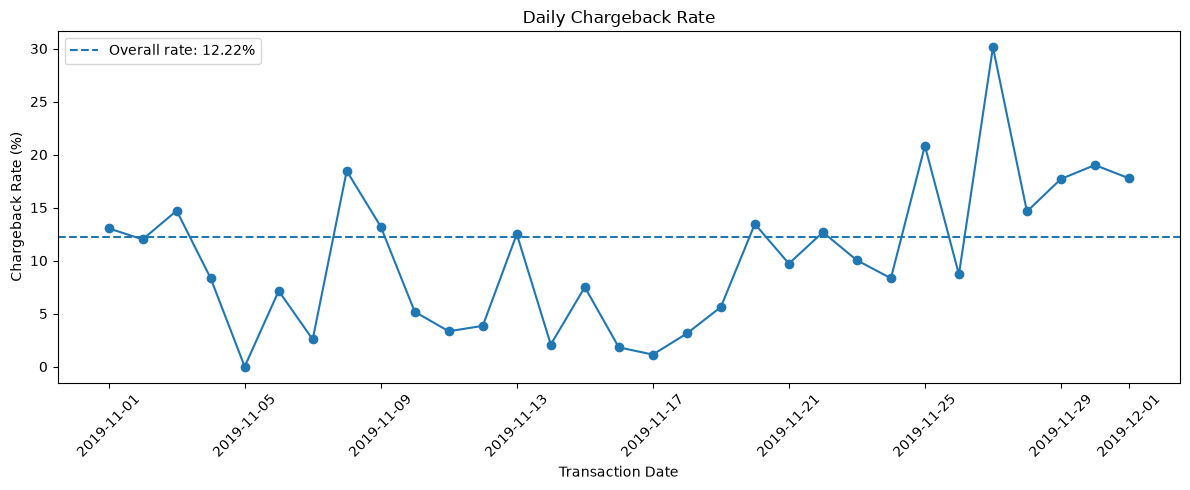

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_activity.index,
    daily_activity["chargeback_rate"],
    marker="o",
)

plt.axhline(
    y=chargeback_rate * 100,
    linestyle="--",
    label=f"Overall rate: {chargeback_rate:.2%}",
)

plt.title("Daily Chargeback Rate")
plt.xlabel("Transaction Date")
plt.ylabel("Chargeback Rate (%)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

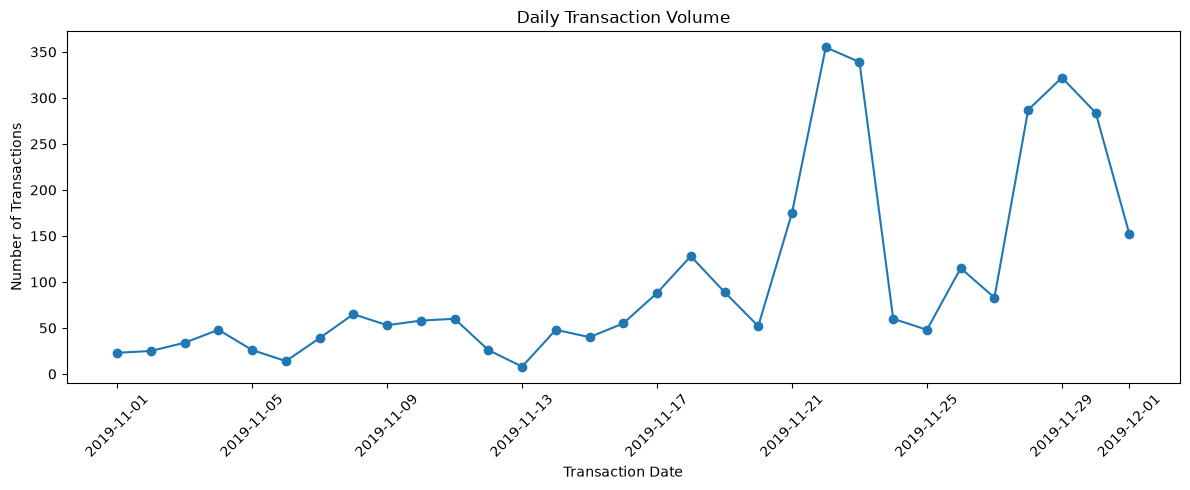

In [18]:
daily_volume = (
    df.assign(transaction_date=pd.to_datetime(df["transaction_date"]).dt.date)
    .groupby("transaction_date")
    .size()
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_volume.index,
    daily_volume.values,
    marker="o",
)

plt.title("Daily Transaction Volume")
plt.xlabel("Transaction Date")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
daily_analysis = (
    df.assign(
        transaction_date=pd.to_datetime(df["transaction_date"]).dt.date
    )
    .groupby("transaction_date")
    .agg(
        transactions=("transaction_id", "count"),
        chargebacks=("has_cbk", "sum"),
    )
)

daily_analysis["chargeback_rate"] = (
    daily_analysis["chargebacks"]
    / daily_analysis["transactions"]
)

daily_analysis.sort_values(
    "chargeback_rate",
    ascending=False
).head(10)

,transactions,chargebacks,chargeback_rate
transaction_date,,,
2019-11-27,83,25,0.301205
2019-11-25,48,10,0.208333
2019-11-30,284,54,0.190141
2019-11-08,65,12,0.184615
2019-12-01,152,27,0.177632
2019-11-29,322,57,0.177019
2019-11-03,34,5,0.147059
2019-11-28,287,42,0.146341
2019-11-20,52,7,0.134615


In [20]:
amount_by_cbk = (
    df.groupby("has_cbk")["transaction_amount"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
)

amount_by_cbk

,count,mean,median,min,max
has_cbk,,,,,
False,2808,672.324380,360.315,1.22,4091.83
True,391,1453.571918,999.470,2.89,4097.21


<Figure size 800x500 with 0 Axes>

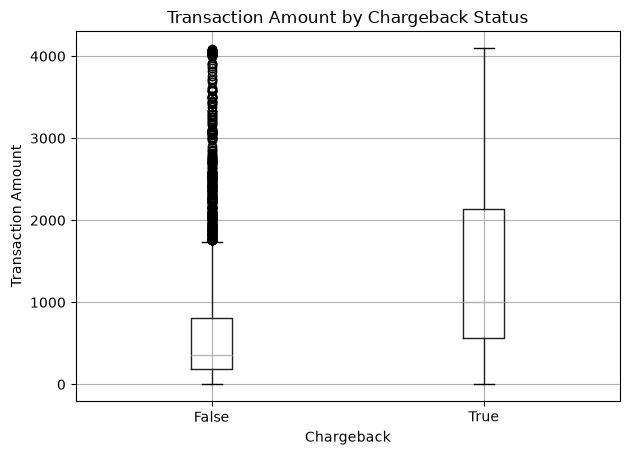

In [21]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="transaction_amount",
    by="has_cbk",
)

plt.title("Transaction Amount by Chargeback Status")
plt.suptitle("")
plt.xlabel("Chargeback")
plt.ylabel("Transaction Amount")

plt.tight_layout()
plt.show()

In [22]:
amount_bins = [0, 100, 500, 1000, 2000, 3000, 5000]

amount_analysis = (
    df.assign(
        amount_range=pd.cut(
            df["transaction_amount"],
            bins=amount_bins,
            right=False,
        )
    )
    .groupby("amount_range", observed=False)
    .agg(
        transactions=("transaction_id", "count"),
        chargebacks=("has_cbk", "sum"),
    )
)

amount_analysis["chargeback_rate"] = (
    amount_analysis["chargebacks"]
    / amount_analysis["transactions"]
)

amount_analysis

,transactions,chargebacks,chargeback_rate
amount_range,,,
"[0, 100)",472,14,0.029661
"[100, 500)",1307,55,0.042081
"[500, 1000)",640,127,0.198437
"[1000, 2000)",423,75,0.177305
"[2000, 3000)",215,67,0.311628
"[3000, 5000)",142,53,0.373239


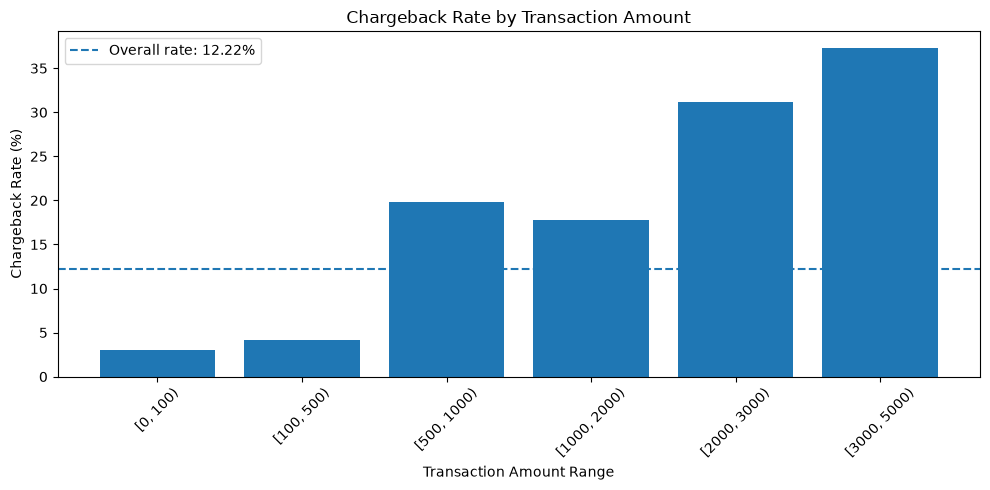

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    amount_analysis.index.astype(str),
    amount_analysis["chargeback_rate"] * 100,
)

plt.axhline(
    y=chargeback_rate * 100,
    linestyle="--",
    label=f"Overall rate: {chargeback_rate:.2%}",
)

plt.title("Chargeback Rate by Transaction Amount")
plt.xlabel("Transaction Amount Range")
plt.ylabel("Chargeback Rate (%)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
user_analysis = (
    df.groupby("user_id")
    .agg(
        transactions=("transaction_id", "count"),
        chargebacks=("has_cbk", "sum"),
        total_amount=("transaction_amount", "sum"),
    )
)

user_analysis["chargeback_rate"] = (
    user_analysis["chargebacks"]
    / user_analysis["transactions"]
)

user_analysis.sort_values(
    "chargebacks",
    ascending=False
).head(10)

,transactions,chargebacks,total_amount,chargeback_rate
user_id,,,,
11750,31,25,17816.26,0.806452
91637,22,19,17335.51,0.863636
79054,17,15,35497.93,0.882353
96025,14,13,30200.22,0.928571
78262,13,12,39195.13,0.923077
75710,10,10,5613.81,1.000000
7725,7,7,10822.94,1.000000
17929,6,6,21840.69,1.000000
21768,6,6,5152.61,1.000000


In [25]:
user_analysis[user_analysis["transactions"] >= 5].sort_values(
    "chargeback_rate",
    ascending=False
).head(15)

,transactions,chargebacks,total_amount,chargeback_rate
user_id,,,,
7725,7,7,10822.94,1.000000
17929,6,6,21840.69,1.000000
28218,5,5,2966.17,1.000000
21768,6,6,5152.61,1.000000
71424,5,5,2966.74,1.000000
99396,5,5,10059.33,1.000000
86411,5,5,7975.64,1.000000
75710,10,10,5613.81,1.000000
96025,14,13,30200.22,0.928571


In [26]:
high_risk_users = user_analysis[
    (user_analysis["transactions"] >= 5)
    & (user_analysis["chargeback_rate"] >= 0.80)
]

high_risk_user_summary = {
    "users": len(high_risk_users),
    "transactions": high_risk_users["transactions"].sum(),
    "chargebacks": high_risk_users["chargebacks"].sum(),
    "chargeback_share": (
        high_risk_users["chargebacks"].sum()
        / df["has_cbk"].sum()
    ),
}

high_risk_user_summary

{'users': 15,
 'transactions': np.int64(156),
 'chargebacks': np.int64(141),
 'chargeback_share': np.float64(0.36061381074168797)}

In [27]:
merchant_analysis = (
    df.groupby("merchant_id")
    .agg(
        transactions=("transaction_id", "count"),
        chargebacks=("has_cbk", "sum"),
        total_amount=("transaction_amount", "sum"),
    )
)

merchant_analysis["chargeback_rate"] = (
    merchant_analysis["chargebacks"]
    / merchant_analysis["transactions"]
)

merchant_analysis.sort_values(
    "chargebacks",
    ascending=False
).head(10)

,transactions,chargebacks,total_amount,chargeback_rate
merchant_id,,,,
17275,30,22,17119.72,0.733333
4705,22,19,17335.51,0.863636
1308,15,15,34517.94,1.000000
53041,19,14,21079.55,0.736842
77130,15,13,6249.81,0.866667
91972,14,11,39754.74,0.785714
44927,11,11,9218.62,1.000000
73271,10,10,14577.57,1.000000
55854,11,9,5518.01,0.818182


In [28]:
high_risk_merchants = merchant_analysis[
    (merchant_analysis["transactions"] >= 5)
    & (merchant_analysis["chargeback_rate"] >= 0.80)
]

high_risk_merchant_summary = {
    "merchants": len(high_risk_merchants),
    "transactions": high_risk_merchants["transactions"].sum(),
    "chargebacks": high_risk_merchants["chargebacks"].sum(),
    "chargeback_share": (
        high_risk_merchants["chargebacks"].sum()
        / df["has_cbk"].sum()
    ),
}

high_risk_merchant_summary

{'merchants': 23,
 'transactions': np.int64(193),
 'chargebacks': np.int64(176),
 'chargeback_share': np.float64(0.45012787723785164)}

In [29]:
user_merchant_cbk = (
    df[df["has_cbk"]]
    .groupby(["user_id", "merchant_id"])
    .agg(
        transactions=("transaction_id", "count"),
        total_amount=("transaction_amount", "sum"),
    )
    .sort_values(
        "transactions",
        ascending=False
    )
)

user_merchant_cbk.head(15)

,,transactions,total_amount
user_id,merchant_id,,
91637,4705,19,15352.11
11750,17275,18,10504.73
75710,77130,10,5613.81
96025,1308,10,23997.62
11750,66876,7,4395.20
78262,65330,7,23918.05
7725,73271,7,10822.94
56877,99510,5,4341.26
28218,53041,5,2966.17


In [30]:
user_merchant_analysis = (
    df.groupby(["user_id", "merchant_id"])
    .agg(
        transactions=("transaction_id", "count"),
        chargebacks=("has_cbk", "sum"),
        total_amount=("transaction_amount", "sum"),
    )
)

user_merchant_analysis["chargeback_rate"] = (
    user_merchant_analysis["chargebacks"]
    / user_merchant_analysis["transactions"]
)

user_merchant_analysis.sort_values(
    ["chargebacks", "chargeback_rate"],
    ascending=False
).head(15)

,,transactions,chargebacks,total_amount,chargeback_rate
user_id,merchant_id,,,,
91637,4705,22,19,17335.51,0.863636
11750,17275,23,18,12865.53,0.782609
75710,77130,10,10,5613.81,1.000000
96025,1308,10,10,23997.62,1.000000
7725,73271,7,7,10822.94,1.000000
11750,66876,8,7,4950.73,0.875000
78262,65330,8,7,27914.84,0.875000
28218,53041,5,5,2966.17,1.000000
71424,29214,5,5,2966.74,1.000000


In [31]:
card_users = (
    df.groupby("card_number")["user_id"]
    .nunique()
    .sort_values(ascending=False)
)

card_users.head(15)

card_number
496045******1160    4
550209******6420    3
518454******7187    2
427167******7032    2
459383******1178    2
516292******1671    2
516292******2831    2
490172******3386    2
459313******1805    2
406655******5763    2
516292******1745    2
482425******7128    2
498408******4290    2
406655******7343    2
476333******3122    2
Name: user_id, dtype: int64

In [32]:
card_analysis = (
    df.groupby("card_number")
      .agg(
          transactions=("transaction_id", "count"),
          users=("user_id", "nunique"),
          chargebacks=("has_cbk", "sum")
      )
      .assign(
          chargeback_rate=lambda x: x["chargebacks"] / x["transactions"]
      )
      .query("transactions >= 2")
      .sort_values(
          ["chargebacks", "transactions"],
          ascending=False
      )
)

card_analysis.head(20)

,transactions,users,chargebacks,chargeback_rate
card_number,,,,
554482******7640,10,1,10,1.00
530034******3859,6,1,6,1.00
651653******2256,5,1,5,1.00
441030******2146,4,1,4,1.00
459080******2870,4,1,4,1.00
498406******7104,4,1,4,1.00
530034******8258,4,1,4,1.00
552289******8870,4,1,4,1.00
550209******3098,4,1,3,0.75


In [33]:
shared_cards = (
    card_analysis
    .query("users > 1")
    .sort_values(
        ["chargeback_rate", "transactions"],
        ascending=False
    )
)

shared_cards

,transactions,users,chargebacks,chargeback_rate
card_number,,,,
406655******7343,3,2,3,1.00
464296******3991,3,2,3,1.00
490172******3386,3,2,3,1.00
498408******4290,3,2,3,1.00
406655******4572,2,2,2,1.00
406655******5763,2,2,2,1.00
412177******1138,2,2,2,1.00
606282******4880,2,2,2,1.00
544731******8590,4,2,2,0.50


In [34]:
card_sharing_comparison = (
    df.assign(
        card_shared=df.groupby("card_number")["user_id"]
        .transform("nunique") > 1
    )
    .groupby("card_shared")
    .agg(
        transactions=("transaction_id", "count"),
        chargebacks=("has_cbk", "sum"),
        chargeback_rate=("has_cbk", "mean")
    )
)

card_sharing_comparison

,transactions,chargebacks,chargeback_rate
card_shared,,,
False,3128,367,0.117327
True,71,24,0.338028


In [35]:
device_analysis = (
    df.dropna(subset=["device_id"])
      .groupby("device_id")
      .agg(
          transactions=("transaction_id", "count"),
          users=("user_id", "nunique"),
          cards=("card_number", "nunique"),
          chargebacks=("has_cbk", "sum")
      )
      .assign(
          chargeback_rate=lambda x: x["chargebacks"] / x["transactions"]
      )
      .sort_values(
          ["chargebacks", "transactions"],
          ascending=False
      )
)

device_analysis.head(20)

,transactions,users,cards,chargebacks,chargeback_rate
device_id,,,,,
563499.0,22,1,22,19,0.863636
342890.0,19,1,19,15,0.789474
101848.0,17,1,15,15,0.882353
438940.0,14,1,10,13,0.928571
547440.0,13,1,10,12,0.923077
542535.0,7,1,7,6,0.857143
357277.0,6,1,1,6,1.000000
960729.0,6,1,6,6,1.000000
174844.0,5,1,2,5,1.000000


In [36]:
shared_devices = (
    device_analysis
    .query("users > 1")
    .sort_values(
        ["chargeback_rate", "transactions"],
        ascending=False
    )
)

shared_devices.head(20)

,transactions,users,cards,chargebacks,chargeback_rate
device_id,,,,,


In [37]:
device_sharing_comparison = (
    df.assign(
        device_shared=df["device_id"].map(
            df.groupby("device_id")["user_id"].nunique()
        ) > 1
    )
    .groupby("device_shared")
    .agg(
        transactions=("transaction_id", "count"),
        chargebacks=("has_cbk", "sum"),
        chargeback_rate=("has_cbk", "mean")
    )
)

device_sharing_comparison

,transactions,chargebacks,chargeback_rate
device_shared,,,
False,3199,391,0.122226


In [38]:
device_user_count = (
    df.dropna(subset=["device_id"])
      .groupby("device_id")["user_id"]
      .nunique()
)

shared_devices = device_user_count[device_user_count > 1].index

df["device_shared"] = df["device_id"].isin(shared_devices)

In [39]:
device_analysis = (
    df.groupby("device_shared")
      .agg(
          transactions=("transaction_id", "count"),
          chargebacks=("has_cbk", "sum"),
          chargeback_rate=("has_cbk", "mean")
      )
)

device_analysis

,transactions,chargebacks,chargeback_rate
device_shared,,,
False,3199,391,0.122226


In [40]:
device_user_count = (
    df.dropna(subset=["device_id"])
      .groupby("device_id")["user_id"]
      .nunique()
)

print("Dispositivos com mais de 1 usuário:")
print((device_user_count > 1).sum())

print("\nMaior número de usuários por dispositivo:")
print(device_user_count.max())

Dispositivos com mais de 1 usuário:
0

Maior número de usuários por dispositivo:
1


In [41]:
user_merchant_analysis.head(10)

,,transactions,chargebacks,total_amount,chargeback_rate
user_id,merchant_id,,,,
6,32954,1,0,443.90,0.0
7,35930,1,0,359.68,0.0
8,17348,1,0,2416.70,0.0
19,82477,1,0,165.14,0.0
132,64192,1,0,714.56,0.0
136,49909,1,0,2543.00,0.0
153,29744,1,0,1413.49,0.0
163,52663,1,0,305.28,0.0
167,53593,1,0,75.78,0.0


In [42]:
user_merchant_analysis.sort_values(
    "chargeback_rate",
    ascending=False
).head(20)

,,transactions,chargebacks,total_amount,chargeback_rate
user_id,merchant_id,,,,
31819,52897,3,3,2918.03,1.0
24027,8942,1,1,2079.92,1.0
50699,23017,1,1,4023.15,1.0
17507,38337,1,1,608.00,1.0
13793,91972,1,1,3958.51,1.0
11858,49919,1,1,3988.01,1.0
47604,23722,2,2,121.12,1.0
35138,65241,2,2,5817.84,1.0
3157,62194,1,1,183.73,1.0


In [43]:
user_merchant_analysis[
    user_merchant_analysis["transactions"] >= 3
].sort_values(
    ["chargeback_rate", "transactions"],
    ascending=[False, False]
).head(20)

,,transactions,chargebacks,total_amount,chargeback_rate
user_id,merchant_id,,,,
75710,77130,10,10,5613.81,1.0
96025,1308,10,10,23997.62,1.0
7725,73271,7,7,10822.94,1.0
28218,53041,5,5,2966.17,1.0
71424,29214,5,5,2966.74,1.0
79054,1308,5,5,10520.32,1.0
86411,89943,5,5,7975.64,1.0
99396,38568,5,5,10059.33,1.0
11065,42356,4,4,2427.30,1.0


In [44]:
merchant_analysis = (
    df.groupby("merchant_id")
      .agg(
          transactions=("merchant_id", "size"),
          chargebacks=("has_cbk", "sum"),
          total_amount=("transaction_amount", "sum")
      )
)

merchant_analysis["chargeback_rate"] = (
    merchant_analysis["chargebacks"]
    / merchant_analysis["transactions"]
)

merchant_analysis.sort_values(
    ["chargeback_rate", "transactions"],
    ascending=[False, False]
).head(20)

,transactions,chargebacks,total_amount,chargeback_rate
merchant_id,,,,
1308,15,15,34517.94,1.0
44927,11,11,9218.62,1.0
73271,10,10,14577.57,1.0
38337,6,6,7579.18,1.0
48126,6,6,6326.83,1.0
75917,6,6,15585.84,1.0
81795,6,6,3392.24,1.0
8942,5,5,8255.58,1.0
15326,5,5,7333.26,1.0


In [45]:
merchant_user_analysis = (
    df.groupby("merchant_id")
      .agg(
          transactions=("transaction_id", "count"),
          users=("user_id", "nunique"),
          chargebacks=("has_cbk", "sum"),
          total_amount=("transaction_amount", "sum")
      )
)

merchant_user_analysis["chargeback_rate"] = (
    merchant_user_analysis["chargebacks"]
    / merchant_user_analysis["transactions"]
)

merchant_user_analysis[
    merchant_user_analysis["transactions"] >= 3
].sort_values(
    ["chargeback_rate", "transactions"],
    ascending=[False, False]
).head(20)

,transactions,users,chargebacks,total_amount,chargeback_rate
merchant_id,,,,,
1308,15,2,15,34517.94,1.0
44927,11,3,11,9218.62,1.0
73271,10,3,10,14577.57,1.0
38337,6,3,6,7579.18,1.0
48126,6,2,6,6326.83,1.0
75917,6,2,6,15585.84,1.0
81795,6,2,6,3392.24,1.0
8942,5,2,5,8255.58,1.0
15326,5,2,5,7333.26,1.0


In [46]:
merchant_users = (
    df[df["has_cbk"] == 1]
    .groupby("merchant_id")
    .agg(
        users=("user_id", "nunique"),
        cards=("card_number", "nunique"),
        transactions=("transaction_id", "count"),
        total_amount=("transaction_amount", "sum")
    )
)

merchant_users["chargeback_rate"] = (
    merchant_users["transactions"]
    / merchant_users["transactions"]
)

merchant_users[
    (merchant_users["transactions"] >= 3) &
    (merchant_users["chargeback_rate"] >= 0.8)
].sort_values(
    ["transactions", "users"],
    ascending=[False, False]
).head(20)

,users,cards,transactions,total_amount,chargeback_rate
merchant_id,,,,,
17275,2,22,22,12952.25,1.0
4705,1,19,19,15352.11,1.0
1308,2,8,15,34517.94,1.0
53041,6,8,14,11421.30,1.0
77130,2,2,13,6229.47,1.0
91972,9,11,11,35528.44,1.0
44927,3,4,11,9218.62,1.0
73271,3,8,10,14577.57,1.0
55854,3,4,9,4656.13,1.0


In [47]:
merchant_investigation = (
    df[
        (df["merchant_id"].isin([91972, 53041, 1308])) &
        (df["has_cbk"] == 1)
    ][[
        "merchant_id",
        "user_id",
        "card_number",
        "transaction_date",
        "transaction_amount"
    ]]
    .sort_values(["merchant_id", "user_id", "transaction_date"])
)

merchant_investigation

,merchant_id,user_id,card_number,transaction_date,transaction_amount
728,1308,79054,406655******7948,2019-11-29 02:52:00.400886,2019.47
727,1308,79054,406655******5763,2019-11-29 02:58:04.351521,1834.09
708,1308,79054,406655******5169,2019-11-29 11:40:49.445144,2251.02
705,1308,79054,406655******7948,2019-11-29 11:49:14.553339,2183.76
692,1308,79054,406655******7343,2019-11-29 12:51:17.927921,2231.98
734,1308,96025,406655******5763,2019-11-29 02:02:30.874661,2904.60
731,1308,96025,406655******4608,2019-11-29 02:10:25.828340,2819.59
729,1308,96025,406655******5764,2019-11-29 02:35:55.206318,2774.51
724,1308,96025,406655******4572,2019-11-29 03:17:30.558440,1648.30
723,1308,96025,406655******5764,2019-11-29 03:30:43.934091,2486.70


In [48]:
shared_cards_by_merchant = (
    df[df["has_cbk"] == 1]
    .groupby(["merchant_id", "card_number"])
    .agg(
        users=("user_id", "nunique"),
        transactions=("transaction_id", "count"),
        total_amount=("transaction_amount", "sum")
    )
    .reset_index()
)

shared_cards_by_merchant[
    shared_cards_by_merchant["users"] > 1
].sort_values(
    ["users", "transactions"],
    ascending=[False, False]
)

,merchant_id,card_number,users,transactions,total_amount
8,1308,406655******7343,2,3,6780.44
103,29214,490172******3386,2,3,1843.33
134,42356,498408******4290,2,3,1308.71
6,1308,406655******5763,2,2,4738.69
193,63050,606282******4880,2,2,6072.03


In [49]:
shared_card_details = (
    df[
        df["card_number"].isin(
            shared_cards_by_merchant.loc[
                shared_cards_by_merchant["users"] > 1,
                "card_number"
            ]
        )
    ][[
        "merchant_id",
        "user_id",
        "card_number",
        "transaction_date",
        "transaction_amount",
        "has_cbk"
    ]]
    .sort_values(
        ["merchant_id", "card_number", "transaction_date"]
    )
)

shared_card_details

,merchant_id,user_id,card_number,transaction_date,transaction_amount,has_cbk
734,1308,96025,406655******5763,2019-11-29 02:02:30.874661,2904.60,True
727,1308,79054,406655******5763,2019-11-29 02:58:04.351521,1834.09,True
692,1308,79054,406655******7343,2019-11-29 12:51:17.927921,2231.98,True
596,1308,96025,406655******7343,2019-11-29 16:46:59.421700,2288.47,True
569,1308,96025,406655******7343,2019-11-29 17:42:40.460221,2259.99,True
855,29214,71424,490172******3386,2019-11-28 19:58:08.165115,511.79,True
604,29214,50643,490172******3386,2019-11-29 16:32:37.604510,725.94,True
583,29214,50643,490172******3386,2019-11-29 17:15:34.416959,605.60,True
1078,42356,76422,498408******4290,2019-11-27 19:07:04.682719,452.67,True
1076,42356,76422,498408******4290,2019-11-27 19:10:10.465467,549.90,True


In [50]:
shared_card_temporal = shared_card_details.copy()

shared_card_temporal["transaction_date"] = pd.to_datetime(
    shared_card_temporal["transaction_date"]
)

shared_card_temporal = shared_card_temporal.sort_values(
    ["merchant_id", "card_number", "transaction_date"]
)

shared_card_temporal["previous_user"] = (
    shared_card_temporal
    .groupby(["merchant_id", "card_number"])["user_id"]
    .shift()
)

shared_card_temporal["previous_transaction"] = (
    shared_card_temporal
    .groupby(["merchant_id", "card_number"])["transaction_date"]
    .shift()
)

shared_card_temporal["minutes_since_previous"] = (
    (
        shared_card_temporal["transaction_date"]
        - shared_card_temporal["previous_transaction"]
    )
    .dt.total_seconds()
    / 60
)

shared_card_temporal

,merchant_id,user_id,card_number,transaction_date,transaction_amount,has_cbk,previous_user,previous_transaction,minutes_since_previous
734,1308,96025,406655******5763,2019-11-29 02:02:30.874661,2904.60,True,NaN,NaT,NaN
727,1308,79054,406655******5763,2019-11-29 02:58:04.351521,1834.09,True,96025.0,2019-11-29 02:02:30.874661,55.557948
692,1308,79054,406655******7343,2019-11-29 12:51:17.927921,2231.98,True,NaN,NaT,NaN
596,1308,96025,406655******7343,2019-11-29 16:46:59.421700,2288.47,True,79054.0,2019-11-29 12:51:17.927921,235.691563
569,1308,96025,406655******7343,2019-11-29 17:42:40.460221,2259.99,True,96025.0,2019-11-29 16:46:59.421700,55.683975
855,29214,71424,490172******3386,2019-11-28 19:58:08.165115,511.79,True,NaN,NaT,NaN
604,29214,50643,490172******3386,2019-11-29 16:32:37.604510,725.94,True,71424.0,2019-11-28 19:58:08.165115,1234.490657
583,29214,50643,490172******3386,2019-11-29 17:15:34.416959,605.60,True,50643.0,2019-11-29 16:32:37.604510,42.946874
1078,42356,76422,498408******4290,2019-11-27 19:07:04.682719,452.67,True,NaN,NaT,NaN
1076,42356,76422,498408******4290,2019-11-27 19:10:10.465467,549.90,True,76422.0,2019-11-27 19:07:04.682719,3.096379


In [51]:
print("Transações:", total_transactions)
print("Chargebacks:", total_chargebacks)
print("Chargeback rate:", chargeback_rate)

Transações: 3199
Chargebacks: 391
Chargeback rate: 0.12222569552985307


In [52]:
daily_analysis.sort_values(
    "chargeback_rate",
    ascending=False
).head(10)

,transactions,chargebacks,chargeback_rate
transaction_date,,,
2019-11-27,83,25,0.301205
2019-11-25,48,10,0.208333
2019-11-30,284,54,0.190141
2019-11-08,65,12,0.184615
2019-12-01,152,27,0.177632
2019-11-29,322,57,0.177019
2019-11-03,34,5,0.147059
2019-11-28,287,42,0.146341
2019-11-20,52,7,0.134615


In [53]:
user_analysis.sort_values(
    "chargeback_rate",
    ascending=False
).head(10)

,transactions,chargebacks,total_amount,chargeback_rate
user_id,,,,
39334,1,1,3583.84,1.0
45031,1,1,249.00,1.0
11065,4,4,2427.30,1.0
86219,1,1,1847.38,1.0
50699,1,1,4023.15,1.0
5541,3,3,7624.07,1.0
47604,2,2,121.12,1.0
19820,3,3,8293.61,1.0
21233,2,2,2729.35,1.0


In [54]:
card_analysis.sort_values(
    "chargeback_rate",
    ascending=False
).head(10)

,transactions,users,chargebacks,chargeback_rate
card_number,,,,
554482******7640,10,1,10,1.0
530034******3859,6,1,6,1.0
651653******2256,5,1,5,1.0
441030******2146,4,1,4,1.0
459080******2870,4,1,4,1.0
498406******7104,4,1,4,1.0
530034******8258,4,1,4,1.0
552289******8870,4,1,4,1.0
406655******7343,3,2,3,1.0


In [55]:
amount_analysis

,transactions,chargebacks,chargeback_rate
amount_range,,,
"[0, 100)",472,14,0.029661
"[100, 500)",1307,55,0.042081
"[500, 1000)",640,127,0.198437
"[1000, 2000)",423,75,0.177305
"[2000, 3000)",215,67,0.311628
"[3000, 5000)",142,53,0.373239


In [56]:
priority_merchants = (
    merchant_user_analysis[
        (merchant_user_analysis["transactions"] >= 5) &
        (merchant_user_analysis["chargeback_rate"] >= 0.80)
    ]
    .sort_values(
        ["chargeback_rate", "transactions"],
        ascending=[False, False]
    )
)

priority_merchants

,transactions,users,chargebacks,total_amount,chargeback_rate
merchant_id,,,,,
1308,15,2,15,34517.94,1.000000
44927,11,3,11,9218.62,1.000000
73271,10,3,10,14577.57,1.000000
38337,6,3,6,7579.18,1.000000
48126,6,2,6,6326.83,1.000000
75917,6,2,6,15585.84,1.000000
81795,6,2,6,3392.24,1.000000
8942,5,2,5,8255.58,1.000000
15326,5,2,5,7333.26,1.000000


In [57]:
priority_merchants[
    priority_merchants["users"] >= 2
]

,transactions,users,chargebacks,total_amount,chargeback_rate
merchant_id,,,,,
1308,15,2,15,34517.94,1.000000
44927,11,3,11,9218.62,1.000000
73271,10,3,10,14577.57,1.000000
38337,6,3,6,7579.18,1.000000
48126,6,2,6,6326.83,1.000000
75917,6,2,6,15585.84,1.000000
81795,6,2,6,3392.24,1.000000
8942,5,2,5,8255.58,1.000000
15326,5,2,5,7333.26,1.000000


In [58]:
amount_by_cbk

,count,mean,median,min,max
has_cbk,,,,,
False,2808,672.324380,360.315,1.22,4091.83
True,391,1453.571918,999.470,2.89,4097.21


In [59]:
df[["transaction_date", "user_id", "has_cbk"]].sort_values(
    "transaction_date"
).head(10)

,transaction_date,user_id,has_cbk
3198,2019-11-01 01:27:15.811098,8,False
3197,2019-11-01 01:29:45.799767,7,False
3196,2019-11-01 10:23:50.555604,84486,False
3195,2019-11-01 11:47:02.404963,59275,False
3194,2019-11-01 13:05:34.054967,49581,False
3193,2019-11-01 14:30:36.417602,19248,False
3192,2019-11-01 14:33:11.280461,38415,False
3191,2019-11-01 16:20:00.178559,84944,False
3190,2019-11-01 16:50:32.916048,93741,False
3189,2019-11-01 17:52:57.071163,19,False


## Risk Signals & Behavioral Findings

The exploratory analysis identified several behavioral patterns associated with chargeback transactions in the sample.

### 1. Transaction Amount

Transactions resulting in chargebacks have substantially higher values than non-chargeback transactions.

- Non-chargeback mean: R$ 672.32
- Chargeback mean: R$ 1,453.57
- Non-chargeback median: R$ 360.32
- Chargeback median: R$ 999.47
- Chargeback rate for transactions between R$ 3,000 and R$ 5,000: 37.32%

This indicates an association between higher transaction amounts and increased chargeback incidence in the sample.

### 2. Merchant Concentration

Chargebacks are highly concentrated in a subset of merchants.

Examples include:

- Merchant 1308: 15 transactions, 15 chargebacks (100%)
- Merchant 44927: 11 transactions, 11 chargebacks (100%)
- Merchant 73271: 10 transactions, 10 chargebacks (100%)

These concentrations represent potential merchant-level risk signals requiring further investigation.

### 3. User × Merchant Behavior

Several user-merchant relationships show repeated transactions with chargeback outcomes.

Examples include:

- User 96025 × Merchant 1308: 10 transactions, 10 chargebacks
- User 75710 × Merchant 77130: 10 transactions, 10 chargebacks
- User 7725 × Merchant 73271: 7 transactions, 7 chargebacks

Repeated chargebacks within the same user-merchant relationship suggest concentrated behavioral patterns.

### 4. Shared Payment Cards

Multiple payment cards were observed being used by different users within the same merchant.

The strongest examples include shared cards associated with multiple users and repeated chargeback transactions.

This represents a potential relationship-based risk signal.

### 5. Temporal Proximity

Some transactions involving shared payment cards occurred within short time intervals.

Observed intervals include approximately:

- 3.1 minutes
- 42.9 minutes
- 55.6 minutes

Temporal proximity alone does not establish fraudulent behavior. However, when combined with shared payment instruments, multiple users, and high chargeback concentration, it strengthens the case for further investigation.

### 6. Device Behavior

No device was associated with more than one user in the sample.

Therefore, `device_shared` did not provide a useful risk signal for this dataset and was not considered further.

### Risk Interpretation

The identified patterns should be treated as risk indicators rather than proof of fraud.

The strongest signals in this sample are the combination of:

- higher transaction amounts;
- merchant-level chargeback concentration;
- repeated user-merchant chargebacks;
- shared payment cards across users;
- temporal proximity between related transactions.

Additional data would be required to establish fraudulent intent or causality.